***Tên: Bùi Ngọc Bảo Trân***

***ID: 25MS33062***

<div align="center">

# **PRACTICE 1 - STYLE TRANSFER**

</div>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
import copy

In [2]:
# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
imsize = 320 #if torch.cuda.is_available() else 128  # use small size if no GPU

In [3]:
# 2. Image Pre-processing
loader = transforms.Compose([
    transforms.Resize((imsize, imsize)),
    transforms.ToTensor()])

def image_loader(image_name):
    image = Image.open(image_name).convert("RGB")
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)

content_img = image_loader("content.png")
style_img = image_loader("style.png")
input_img = content_img.clone() # Start with the content image

In [4]:
# 3. The Non-Learnable Model (VGG-19)
# We use the 'features' part and replace MaxPool with AvgPool for smoother gradients
vgg = models.vgg19(pretrained=True).features.to(device).eval()
for param in vgg.parameters():
    param.requires_grad = False

# 4. Loss Functions
class ContentLoss(nn.Module):
    def __init__(self, target,):
        super(ContentLoss, self).__init__()
        self.target = target.detach()

    def forward(self, x):
        self.loss = nn.functional.mse_loss(x, self.target)
        return x

def gram_matrix(input):
    a, b, c, d = input.size()
    features = input.view(a * b, c * d)
    G = torch.mm(features, features.t())
    return G.div(a * b * c * d)

class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, x):
        G = gram_matrix(x)
        self.loss = nn.functional.mse_loss(G, self.target)
        return x

/opt/miniconda3/envs/msa/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/msa/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /Users/bngbtran/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 74.7MB/s] 


In [5]:
# 5. Building the Style Transfer Pipeline
content_layers = ['conv_4']
style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

def get_style_model_and_losses(vgg, style_img, content_img):
    model = nn.Sequential()
    content_losses = []
    style_losses = []
    i = 0
    for layer in vgg.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f'conv_{i}'
        elif isinstance(layer, nn.ReLU):
            name = f'relu_{i}'
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{i}'
            layer = nn.AvgPool2d(kernel_size=layer.kernel_size, stride=layer.stride)

        model.add_module(name, layer)

        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)

    # Trim the layers after the last loss
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], ContentLoss) or isinstance(model[i], StyleLoss):
            break
    model = model[:(i + 1)]

    return model, style_losses, content_losses

In [6]:
# 6. Optimization (L-BFGS)
def run_style_transfer(vgg, content_img, style_img, input_img, num_steps=300, style_weight=1000000, content_weight=1):
    model, style_losses, content_losses = get_style_model_and_losses(vgg, style_img, content_img)
    optimizer = optim.LBFGS([input_img.requires_grad_(True)])

    run = [0]
    while run[0] <= num_steps:
        def closure():
            input_img.data.clamp_(0, 1) # Keep pixel values valid
            optimizer.zero_grad()
            model(input_img)

            s_loss = 0
            c_loss = 0
            for sl in style_losses: s_loss += sl.loss
            for cl in content_losses: c_loss += cl.loss

            loss = s_loss * style_weight + c_loss * content_weight
            loss.backward()

            if run[0] % 50 == 0:
                print(f"Step {run[0]}: Style Loss: {s_loss.item():.4f} Content Loss: {c_loss.item():.4f}")
            run[0] += 1
            return loss

        optimizer.step(closure)

    return input_img.data.clamp_(0, 1)

output = run_style_transfer(vgg, content_img, style_img, input_img)

Step 0: Style Loss: 0.0000 Content Loss: 0.0000
Step 50: Style Loss: 0.0000 Content Loss: 0.6815
Step 100: Style Loss: 0.0000 Content Loss: 0.5793
Step 150: Style Loss: 0.0000 Content Loss: 0.5657
Step 200: Style Loss: 0.0000 Content Loss: 0.5653
Step 250: Style Loss: 0.0000 Content Loss: 0.5761
Step 300: Style Loss: 0.0000 Content Loss: 0.5936


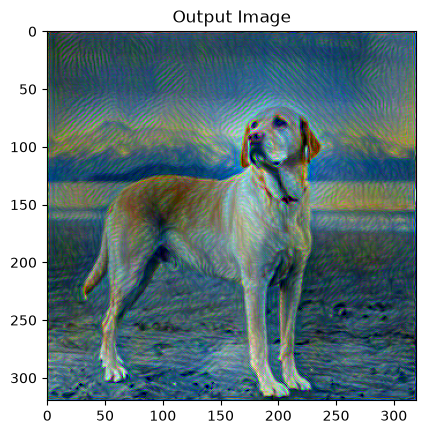

In [7]:
import matplotlib.pyplot as plt

def imshow(tensor, title=None):
    image = tensor.cpu().clone()
    image = image.squeeze(0)      # remove the fake batch dimension
    image = transforms.ToPILImage()(image)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.pause(0.001) # pause a bit so that plots are updated

plt.figure()
imshow(output, title='Output Image')

plt.show()